# 00 — Dataset Extraction & Exploration

Build the aligned **Lakh MIDI ↔ MSD (Million Song Dataset)** table, deduplicate it, and persist it as a Parquet file for downstream notebooks.

**Pipeline**
1. Point to local dataset roots
2. Discover tracks via `LakhMSDLinker`
3. Filter by DTW match score (≥ 0.70)
4. Read MSD HDF5 metadata (h5py)
5. Deduplicate by MIDI hash + artist/title
6. Exploratory statistics & plots
7. Save to `data/processed/lakh_msd_dataset.parquet`

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('..').resolve() / 'src'))

import warnings
warnings.filterwarnings('ignore')

from data.dataset_extraction import LakhMSDLinker, read_msd_metadata, load_dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='whitegrid')
print("Imports OK")

Imports OK


## 0 — Download Lakh MIDI Dataset (run once)

Downloads three assets into `data/raw/` and writes a `manifest.json` so the rest of the notebook can pick up the paths automatically:

| Asset | Size | Destination |
|-------|------|-------------|
| `lmd_matched.tar.gz` | ~1.5 GB | `data/raw/lmd_matched/` |
| `lmd_matched_h5.tar.gz` | ~2.5 GB | `data/raw/lmd_matched_h5/` |
| `match_scores.json` | ~9 MB | `data/raw/match_scores.json` |

> **Skip this cell** if you already have the files — set `SKIP_DOWNLOAD = True`.

In [6]:
import subprocess

SKIP_DOWNLOAD = False          # ← set True once data/raw/ is populated
RAW_DIR       = pathlib.Path('../data/raw').resolve()

if not SKIP_DOWNLOAD:
    result = subprocess.run(
        [sys.executable,
         str(pathlib.Path('..').resolve() / 'scripts' / 'download_lmd.py'),
         '--dest', str(RAW_DIR),
         '--skip-existing'],
        capture_output=False,   # stream output directly to the notebook
        text=True,
    )
    if result.returncode != 0:
        raise RuntimeError("Download script failed — check output above.")
else:
    print("SKIP_DOWNLOAD=True — skipping download.")


  DL-KG-project — Lakh MIDI Dataset downloader
  Destination : data/raw
  Assets      : lmd_matched, lmd_matched_h5, match_scores


── lmd_matched  ──  LMD-matched  (~45 k MIDI files matched to MSD)
    ↓  http://hog.ee.columbia.edu/craffel/lmd/lmd_matched.tar.gz
       → data/raw/lmd_matched.tar.gz  (1.3 GB)
    ↓  http://hog.ee.columbia.edu/craffel/lmd/lmd_matched.tar.gz
       → data/raw/lmd_matched.tar.gz  (1.3 GB)


100%|██████████████████████████████████████| 1.31G/1.31G [02:05<00:00, 11.2MB/s]
100%|██████████████████████████████████████| 1.31G/1.31G [02:05<00:00, 11.2MB/s]


       ✓  1.3 GB in 125.3s
    ↩  Already unpacked  (116,189 files in data/raw/lmd_matched)

── lmd_matched_h5  ──  MSD HDF5 files for every LMD-matched entry
    ↩  Already unpacked  (116,189 files in data/raw/lmd_matched)

── lmd_matched_h5  ──  MSD HDF5 files for every LMD-matched entry
    ↓  http://hog.ee.columbia.edu/craffel/lmd/lmd_matched_h5.tar.gz
       → data/raw/lmd_matched_h5.tar.gz  (6.2 GB)
    ↓  http://hog.ee.columbia.edu/craffel/lmd/lmd_matched_h5.tar.gz
       → data/raw/lmd_matched_h5.tar.gz  (6.2 GB)


100%|██████████████████████████████████████| 6.18G/6.18G [14:08<00:00, 7.82MB/s]
100%|██████████████████████████████████████| 6.18G/6.18G [14:08<00:00, 7.82MB/s]


       ✓  6.2 GB in 849.0s
    📦 Unpacking lmd_matched_h5.tar.gz → data/raw/lmd_matched_h5 …


100%|█████████████████████████████████| 46332/46332 [00:59<00:00, 781.24files/s]


    ✓  31,034 files extracted → data/raw/lmd_matched_h5

── match_scores  ──  DTW match scores (track_id → md5 → score)
    ↩  Already exists — skipping  (6.9 MB)

  ✓  Done.  Manifest → data/raw/manifest.json



In [7]:
# ── Auto-detect paths from the manifest written by download_lmd.py ───────────
import json as _json

_manifest_path = RAW_DIR / 'manifest.json'

if _manifest_path.exists():
    with open(_manifest_path) as _f:
        _manifest = _json.load(_f)

    MIDI_ROOT_AUTO         = pathlib.Path(_manifest['lmd_matched']['unpacked'])
    H5_ROOT_AUTO           = pathlib.Path(_manifest['lmd_matched_h5']['unpacked'])
    MATCH_SCORES_PATH_AUTO = pathlib.Path(_manifest['match_scores']['archive'])

    print("Paths loaded from manifest:")
    print(f"  MIDI root        : {MIDI_ROOT_AUTO}")
    print(f"  HDF5 root        : {H5_ROOT_AUTO}")
    print(f"  Match scores     : {MATCH_SCORES_PATH_AUTO}")
    print(f"  MIDI exists      : {MIDI_ROOT_AUTO.exists()}")
    print(f"  HDF5 exists      : {H5_ROOT_AUTO.exists()}")
    print(f"  Scores exists    : {MATCH_SCORES_PATH_AUTO.exists()}")
else:
    # fallback — set manually below
    MIDI_ROOT_AUTO         = pathlib.Path('/path/to/lmd_matched')
    H5_ROOT_AUTO           = pathlib.Path('/path/to/lmd_matched_h5')
    MATCH_SCORES_PATH_AUTO = pathlib.Path('/path/to/match_scores.json')
    print("[WARN] manifest.json not found — set paths manually in the next cell.")

Paths loaded from manifest:
  MIDI root        : /home/pfanyka/Desktop/MASTERS/sem_2/KG_DL_PROJECT/DL-KG-project/data/raw/lmd_matched
  HDF5 root        : /home/pfanyka/Desktop/MASTERS/sem_2/KG_DL_PROJECT/DL-KG-project/data/raw/lmd_matched_h5
  Match scores     : /home/pfanyka/Desktop/MASTERS/sem_2/KG_DL_PROJECT/DL-KG-project/data/raw/match_scores.json
  MIDI exists      : True
  HDF5 exists      : True
  Scores exists    : True


## 1 — Configuration: dataset roots

In [8]:
# ── Override here only if you want to use paths different from the manifest ──
MIDI_ROOT         = MIDI_ROOT_AUTO           # or: pathlib.Path('/custom/path')
H5_ROOT           = H5_ROOT_AUTO
MATCH_SCORES_PATH = MATCH_SCORES_PATH_AUTO

PROCESSED_DIR = pathlib.Path('../data/processed')
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

OUT_PARQUET = PROCESSED_DIR / 'lakh_msd_dataset.parquet'

MIN_SCORE  = 0.70   # DTW threshold — keep scores ≤ this (lower = better fit)
MAX_TRACKS = None   # int (e.g. 5_000) for a quick test run, None = all

# ── Sanity-check ─────────────────────────────────────────────────────────────
for label, p in [('MIDI root', MIDI_ROOT),
                 ('HDF5 root', H5_ROOT),
                 ('match_scores', MATCH_SCORES_PATH)]:
    status = '✓' if p.exists() else '✗ NOT FOUND'
    print(f"  {status}  {label}: {p}")


  ✓  MIDI root: /home/pfanyka/Desktop/MASTERS/sem_2/KG_DL_PROJECT/DL-KG-project/data/raw/lmd_matched
  ✓  HDF5 root: /home/pfanyka/Desktop/MASTERS/sem_2/KG_DL_PROJECT/DL-KG-project/data/raw/lmd_matched_h5
  ✓  match_scores: /home/pfanyka/Desktop/MASTERS/sem_2/KG_DL_PROJECT/DL-KG-project/data/raw/match_scores.json


## 2 — Build dataset (discover → filter → read HDF5 → deduplicate)

In [9]:
linker = LakhMSDLinker(
    midi_root          = MIDI_ROOT,
    h5_root            = H5_ROOT,
    match_scores_path  = MATCH_SCORES_PATH,
    min_score          = MIN_SCORE,
    pick_midi          = 'best',   # one row per MSD track
)

df = linker.build_dataset(max_tracks=MAX_TRACKS, verbose=True)
print(f"\nDataset shape: {df.shape}")
df.head(3)

Reading HDF5 metadata: 100%|██████████| 15947/15947 [02:06<00:00, 126.16it/s]



Dedup: 10816 → 10529 rows (removed 287 duplicates by artist+title)

Dataset shape: (10529, 51)


,track_id,midi_path,match_score,song_id,artist_id,artist_mbid,artist_playmeid,artist_7digitalid,release_7digitalid,track_7digitalid,...,top3_genres,similar_artists,mbtags,mbtags_count,mean_chroma,mean_timbre,beats_count,bars_count,sections_count,tatums_count
0,TRRCFSV128F92E6644,/home/pfanyka/Desktop/MASTERS/sem_2/KG_DL_PROJ...,0.500043,SOYOZGC12AB0183541,ARFWL8S1187B9B4B44,847e8a0c-cc20-4213-9e16-975515c2a926,309,90222,329131,3700349,...,"[rock, soft rock, pop rock]",[],[],[],None,None,None,None,None,None
1,TROSQNP128F92C5073,/home/pfanyka/Desktop/MASTERS/sem_2/KG_DL_PROJ...,0.500044,SOZMEWR12A6701EBD9,AR2GFJV1187B9A4805,49afd610-0265-4ab1-9e13-f0cc98e33e1d,3327,1418,313481,3546037,...,"[jazz, rock, smooth jazz]",[],[],[],None,None,None,None,None,None
2,TRUQIYJ128F935343C,/home/pfanyka/Desktop/MASTERS/sem_2/KG_DL_PROJ...,0.500057,SOCQCJT12A8C12FCA9,AR5V9Y81187FB57DBA,09ff1fe8-d61c-4b98-bb82-18487c74d7b7,327,184971,519586,5748575,...,"[classical, chill-out, waltz]",[],[],[],None,None,None,None,None,None


In [14]:
# set max columns to None to show all columns in the dataframe
pd.set_option('display.max_columns', None)
df.head(3)

,track_id,midi_path,match_score,song_id,artist_id,artist_mbid,artist_playmeid,artist_7digitalid,release_7digitalid,track_7digitalid,audio_md5,artist_name,title,release,artist_location,artist_latitude,artist_longitude,artist_familiarity,artist_hotttnesss,song_hotttnesss,msd_key,key_name,key_confidence,msd_mode,mode_name,mode_confidence,msd_tempo,msd_time_sig,time_sig_confidence,msd_duration,end_of_fade_in,start_of_fade_out,analysis_sample_rate,msd_loudness,msd_danceability,msd_energy,year,artist_terms,artist_terms_freq,artist_terms_weight,primary_genre,top3_genres,similar_artists,mbtags,mbtags_count,mean_chroma,mean_timbre,beats_count,bars_count,sections_count,tatums_count
0,TRRCFSV128F92E6644,/home/pfanyka/Desktop/MASTERS/sem_2/KG_DL_PROJ...,0.500043,SOYOZGC12AB0183541,ARFWL8S1187B9B4B44,847e8a0c-cc20-4213-9e16-975515c2a926,309,90222,329131,3700349,19247dba0c8eea6f78fbdd6042f65d8c,Céline Dion,Pour Que Tu M'Aimes Encore,My Love Ultimate Essential Collection,"Charlemagne, Quebec, Canada",NaN,NaN,0.737437,0.663686,NaN,2,D,0.542,1,major,0.648,90.196,4,0.715,254.43220,0.222,236.815,22050,-8.923,0.0,0.0,1995.0,"[soft rock, pop rock, rock, adult contemporary...","[0.9998294961820198, 0.9998294961820198, 1.0, ...","[1.0, 0.9463389099187155, 0.7935410121482775, ...",rock,"[rock, soft rock, pop rock]",[],[],[],None,None,None,None,None,None
1,TROSQNP128F92C5073,/home/pfanyka/Desktop/MASTERS/sem_2/KG_DL_PROJ...,0.500044,SOZMEWR12A6701EBD9,AR2GFJV1187B9A4805,49afd610-0265-4ab1-9e13-f0cc98e33e1d,3327,1418,313481,3546037,7300cbb53774f2bc9eb21f789b76ad54,Jan Hammer,Crockett's Theme,Total Workout 80s Pop 118BPM - 137BPM - 97BPM ...,"Prague, Czechoslovakia",50.07908,14.43322,0.615419,0.492369,0.810745,7,G,0.605,0,minor,0.574,191.320,4,0.625,204.43383,0.226,190.984,22050,-13.036,0.0,0.0,1987.0,"[instrumental rock, smooth jazz, fusion, chill...","[0.9833476028580395, 0.9931316271625567, 0.919...","[1.0, 0.9825728060769346, 0.8796347330234463, ...",jazz,"[jazz, rock, smooth jazz]",[],[],[],None,None,None,None,None,None
2,TRUQIYJ128F935343C,/home/pfanyka/Desktop/MASTERS/sem_2/KG_DL_PROJ...,0.500057,SOCQCJT12A8C12FCA9,AR5V9Y81187FB57DBA,09ff1fe8-d61c-4b98-bb82-18487c74d7b7,327,184971,519586,5748575,3f00b56c72c26e521ebaf465a9d1cd14,The London Fox Orchestra,Polonaise In A-Flat Major Op. 53,Great Composers Collection: Frederic Chopin,"Żelazowa Wola, Poland",52.23813,20.97151,0.689633,0.479660,NaN,8,G#,0.625,1,major,0.527,96.846,1,0.564,400.19546,1.431,389.526,22050,-18.746,0.0,0.0,NaN,"[chill-out, waltz, italian disco, classical, g...","[0.9197784362027336, 0.9163233700502093, 0.872...","[1.0, 0.997146057472267, 0.9609851902016915, 0...",classical,"[classical, chill-out, waltz]",[],[],[],None,None,None,None,None,None


In [10]:
# Quick summary of nulls and dtypes
print("=== NULL counts (top 20) ===")
print(df.isnull().sum().sort_values(ascending=False).head(20))
print("\n=== dtypes ===")
print(df.dtypes.value_counts())

=== NULL counts (top 20) ===
mean_timbre           10529
tatums_count          10529
sections_count        10529
mean_chroma           10529
bars_count            10529
beats_count           10529
artist_latitude        7003
artist_longitude       7003
song_hotttnesss        4993
year                   4723
artist_location        4394
artist_mbid             703
primary_genre           148
artist_familiarity        2
track_id                  0
match_score               0
song_id                   0
artist_id                 0
midi_path                 0
artist_hotttnesss         0
dtype: int64

=== dtypes ===
float64    17
str        13
object     13
int64       8
Name: count, dtype: int64


## 3 — Exploratory statistics

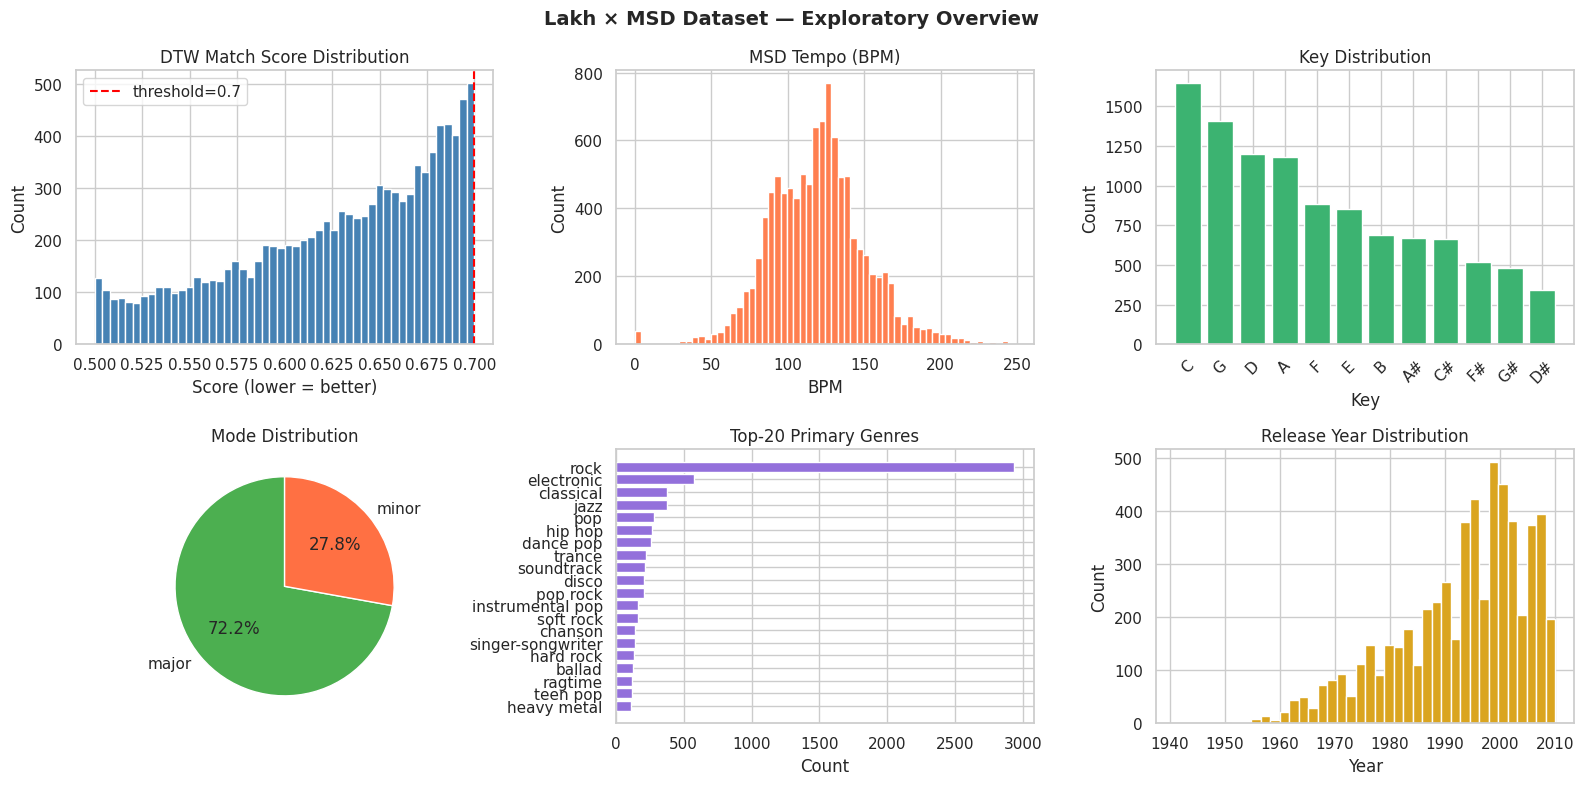

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Lakh × MSD Dataset — Exploratory Overview', fontsize=14, fontweight='bold')

# 1. Match score distribution
ax = axes[0, 0]
ax.hist(df['match_score'].dropna(), bins=50, color='steelblue', edgecolor='white')
ax.set(title='DTW Match Score Distribution', xlabel='Score (lower = better)', ylabel='Count')
ax.axvline(MIN_SCORE, color='red', linestyle='--', label=f'threshold={MIN_SCORE}')
ax.legend()

# 2. Tempo
ax = axes[0, 1]
ax.hist(df['msd_tempo'].dropna(), bins=60, color='coral', edgecolor='white')
ax.set(title='MSD Tempo (BPM)', xlabel='BPM', ylabel='Count')

# 3. Key distribution
ax = axes[0, 2]
key_counts = df['key_name'].value_counts()
ax.bar(key_counts.index, key_counts.values, color='mediumseagreen')
ax.set(title='Key Distribution', xlabel='Key', ylabel='Count')
ax.tick_params(axis='x', rotation=45)

# 4. Mode (major / minor)
ax = axes[1, 0]
mode_counts = df['mode_name'].value_counts()
ax.pie(mode_counts.values, labels=mode_counts.index, autopct='%1.1f%%',
       colors=['#4CAF50', '#FF7043'], startangle=90)
ax.set_title('Mode Distribution')

# 5. Top-20 genres
ax = axes[1, 1]
genre_counts = df['primary_genre'].dropna().value_counts().head(20)
ax.barh(genre_counts.index[::-1], genre_counts.values[::-1], color='mediumpurple')
ax.set(title='Top-20 Primary Genres', xlabel='Count')

# 6. Year distribution
ax = axes[1, 2]
years = df['year'].dropna()
years = years[(years > 1900) & (years <= 2023)]
ax.hist(years, bins=40, color='goldenrod', edgecolor='white')
ax.set(title='Release Year Distribution', xlabel='Year', ylabel='Count')

plt.tight_layout()
plt.show()

In [12]:
print("=== Numeric summary ===")
num_cols = ['match_score','msd_tempo','msd_duration','msd_loudness',
            'msd_danceability','msd_energy','key_confidence','mode_confidence']
df[num_cols].describe().round(3)

=== Numeric summary ===


,match_score,msd_tempo,msd_duration,msd_loudness,msd_danceability,msd_energy,key_confidence,mode_confidence
count,10529.000,10529.000,10529.000,10529.000,10529.0,10529.0,10529.000,10529.000
mean,0.628,119.662,245.135,-11.174,0.0,0.0,0.496,0.527
std,0.055,31.513,92.876,6.090,0.0,0.0,0.272,0.190
min,0.500,0.000,0.626,-39.815,0.0,0.0,0.000,0.000
25%,0.590,97.761,192.862,-13.636,0.0,0.0,0.297,0.414
50%,0.640,120.020,233.299,-9.562,0.0,0.0,0.524,0.541
75%,0.675,137.511,280.006,-6.938,0.0,0.0,0.696,0.658
max,0.700,248.405,2149.329,1.244,0.0,0.0,1.000,1.000


## 4 — Save processed dataset

In [13]:
df.to_parquet(OUT_PARQUET, index=False)
print(f"Saved {len(df):,} rows → {OUT_PARQUET}")

# also save a lighter CSV (without list columns) for quick inspection
csv_cols = [c for c in df.columns if not isinstance(df[c].iloc[0], list)]
df[csv_cols].to_csv(OUT_PARQUET.with_suffix('.csv'), index=False)
print("CSV saved (no list columns).")

Saved 10,529 rows → ../data/processed/lakh_msd_dataset.parquet
CSV saved (no list columns).
CSV saved (no list columns).
